In [1]:
import xarray as xr
import xscen as xs
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
import glob
import xclim as xc
from xscen import CONFIG
import cartopy.crs as ccrs
from matplotlib import gridspec
import copy
import xsdba as xa
xs.load_config("config/config_general.yml","config/config_region.yml","config/paths.yml")


import figanos.matplotlib as fg 
fg.utils.set_mpl_style('ouranos')

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [10]:
pcat = xs.ProjectCatalog(
    #f"{CONFIG['paths']['finaldir']}/compare-cat.json",#TODO
    "/project/ctb-frigon/julavoie/MBCn-test/compare-cat.json",
    create=True,
    project= {
    "title": "compare-catalog",
    "description": "Catalog for comapring DQM and MBCn.",
},
   #overwrite=True
)

In [3]:
# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir'].replace('MBCn-test', 'DQM-test')}/diagnostics/NAM-E5L/',
# ],
#     patterns=[
#         "{domain}/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_NAM-E5L_{domain}_{processing_level}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "DQM",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir']}/diagnostics/NAM-E5L/',
# ],
#     patterns=[
#         "{domain}/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_NAM-E5L_{domain}_{processing_level}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "MBCn",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir'].replace('MBCn-test', 'DQM-test')}/diagnostics/NAM-E5L/',
# ],
#     patterns=[
#         "{domain}/{processing_level:_}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "DQM",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir']}/diagnostics/NAM-E5L/',
# ],
#     patterns=[
#         "{domain}/{processing_level:_}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "MBCn",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

2025-07-08 13:09:09 INFO     xscen.catutils  Parsing attributes with xarray from /project/ctb-frigon/julavoie/DQM-test/diagnostics/NAM-E5L/Magtogoek/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_Magtogoek_scen-prop.zarr.zip.
2025-07-08 13:09:09 INFO     xscen.catutils  Parsing attributes with xarray from /project/ctb-frigon/julavoie/DQM-test/diagnostics/NAM-E5L/Magtogoek/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_Magtogoek_sim-prop.zarr.zip.
2025-07-08 13:09:09 INFO     xscen.catutils  Parsing attributes with xarray from /project/ctb-frigon/julavoie/DQM-test/diagnostics/NAM-E5L/Magtogoek/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_Magtogoek_scen-meas.zarr.zip.
2025-07-08 13:09:09 INFO     xscen.catutils  Parsi

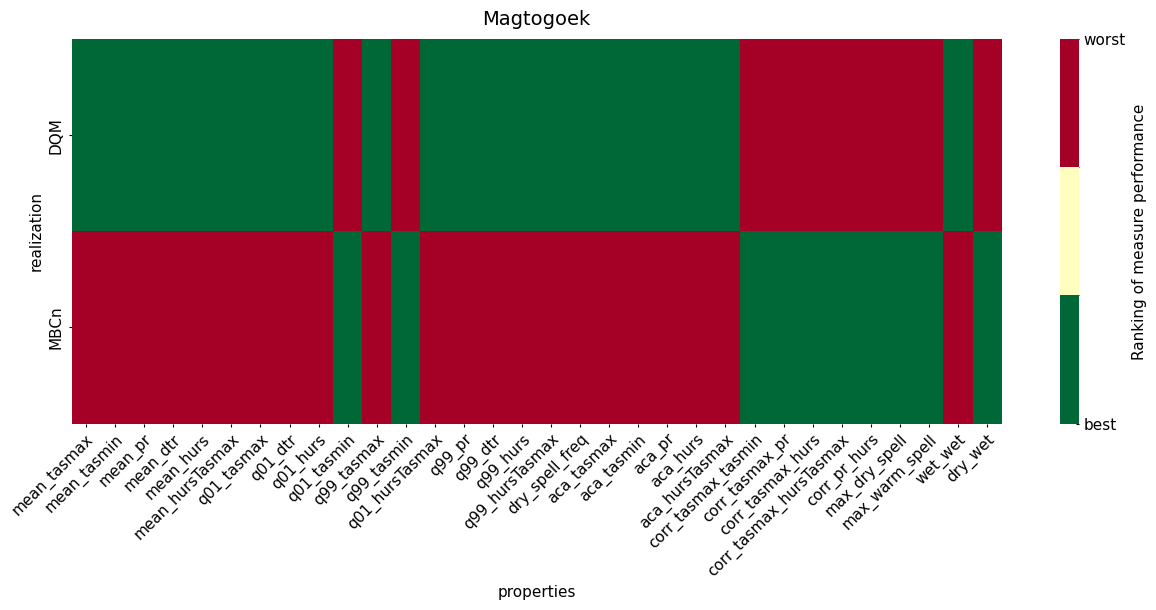

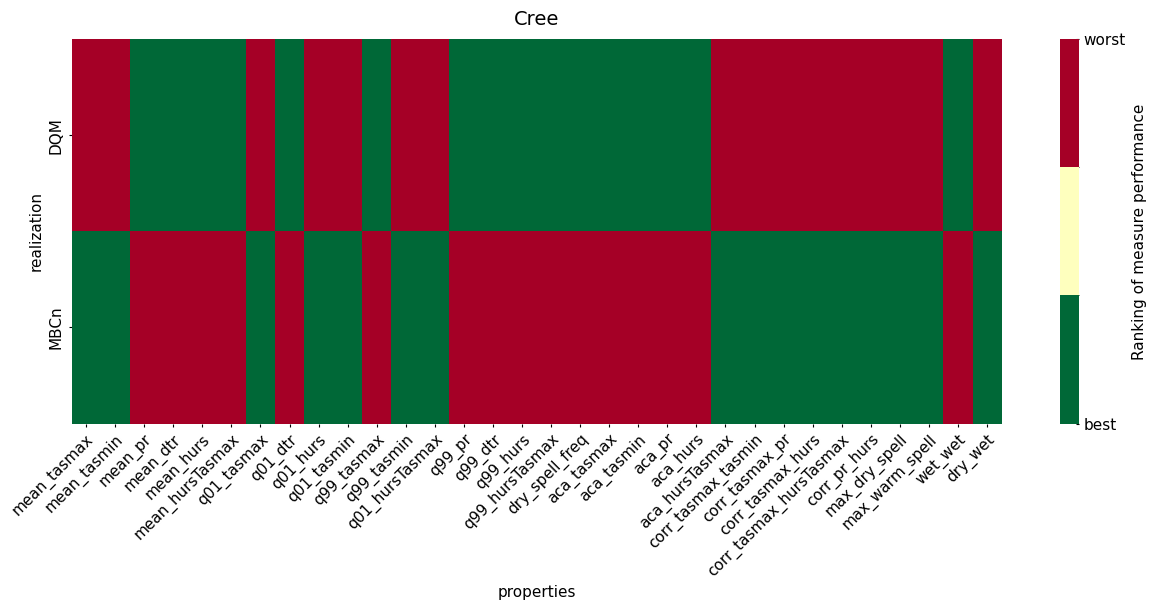

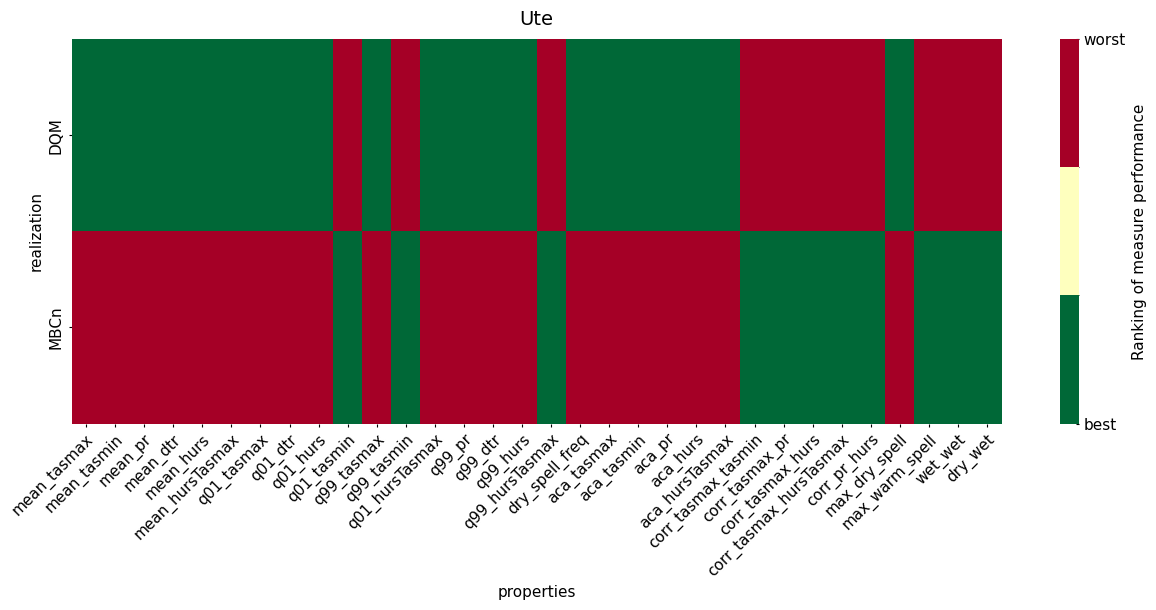

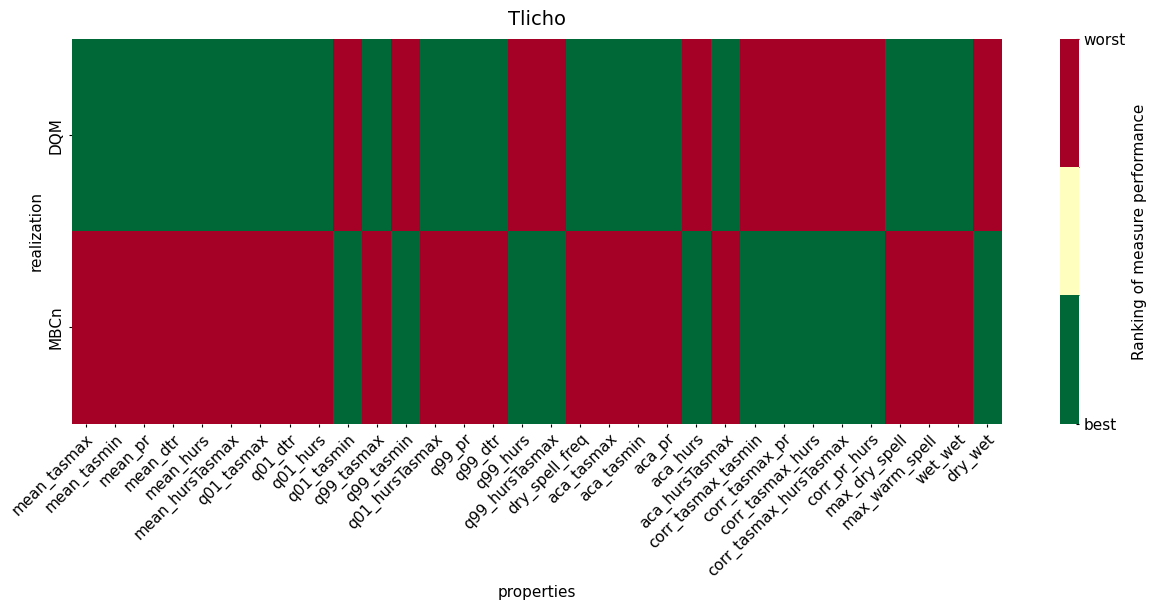

In [4]:

cmap = plt.cm.RdYlGn_r
norm = colors.BoundaryNorm(np.linspace(0, 1, 4), cmap.N)

for r in ['Magtogoek','Cree','Ute','Tlicho']:
    #ds_dqm=xr.open_zarr(f'/project/ctb-frigon/julavoie/DQM-test/diagnostics/NAM-E5L/{r}/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_{r}_scen-meas.zarr.zip')
    #ds_mbcn=xr.open_zarr(f'/project/ctb-frigon/julavoie/MBCn-test/diagnostics/NAM-E5L/{r}/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_{r}_scen-meas.zarr.zip')
    ds_dqm=pcat.search(domain=r, bias_adjust_project='DQM', processing_level='scen-meas').to_dataset()
    ds_mbcn=pcat.search(domain=r, bias_adjust_project='MBCn', processing_level='scen-meas').to_dataset()

    # fix order
    ds_dqm=ds_dqm[["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_dtr","q01_hurs","q01_tasmin","q99_tasmax","q99_tasmin","q01_hursTasmax","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",]]
    ds_mbcn=ds_mbcn[["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_dtr","q01_hurs","q01_tasmin","q99_tasmax","q99_tasmin","q01_hursTasmax","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",]]

    ds_map = xs.diagnostics.measures_heatmap({'DQM':ds_dqm,'MBCn':ds_mbcn})
    ax=fg.heatmap(ds_map, plot_kw=dict(cmap=cmap, norm=norm), fig_kw={'figsize':(15,5)})
    ax.figure.axes[1].set_yticks([0,1], labels=["best", "worst"])
    ax.set_title(r)

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.


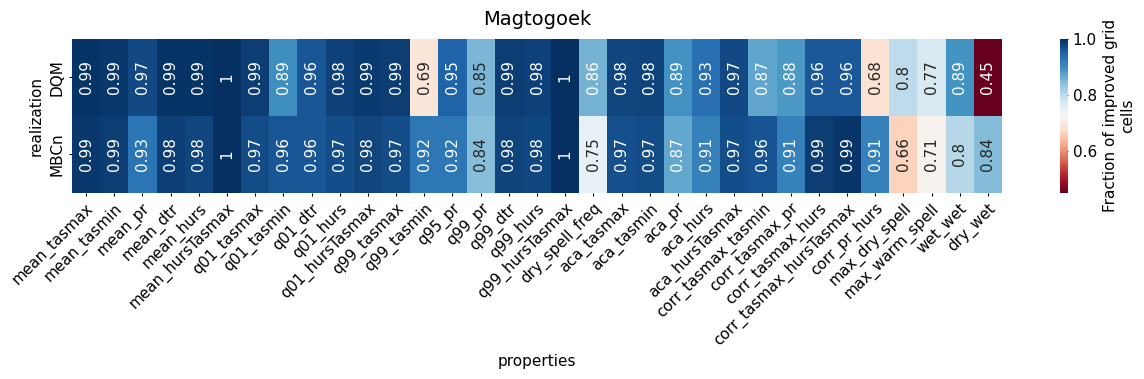

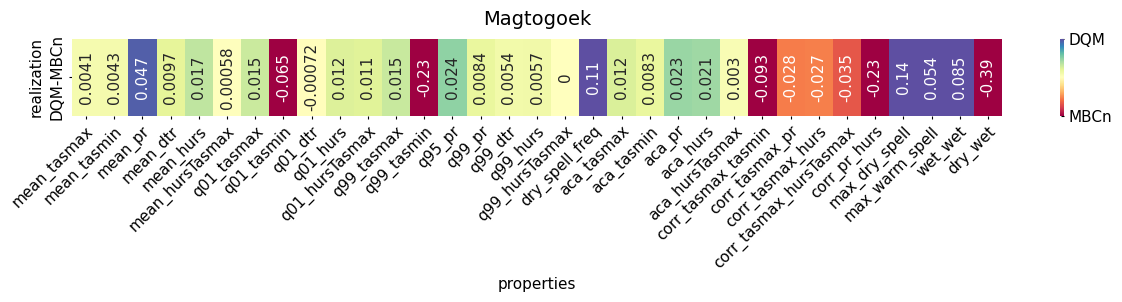

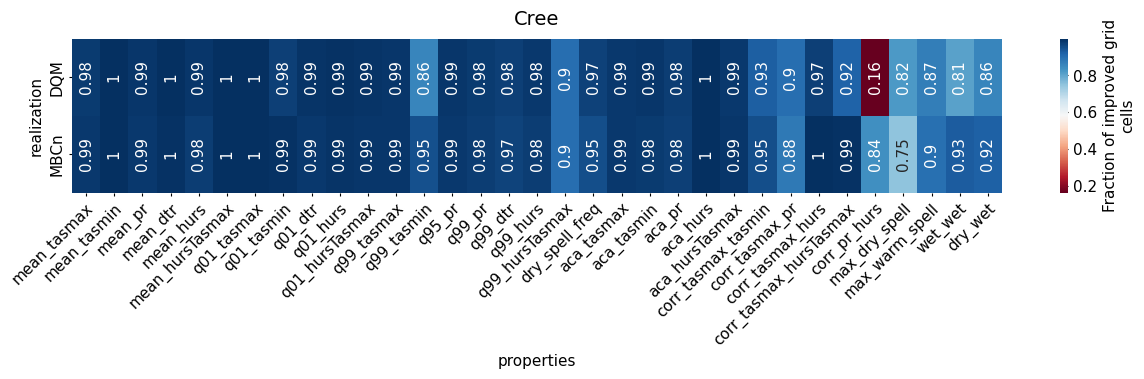

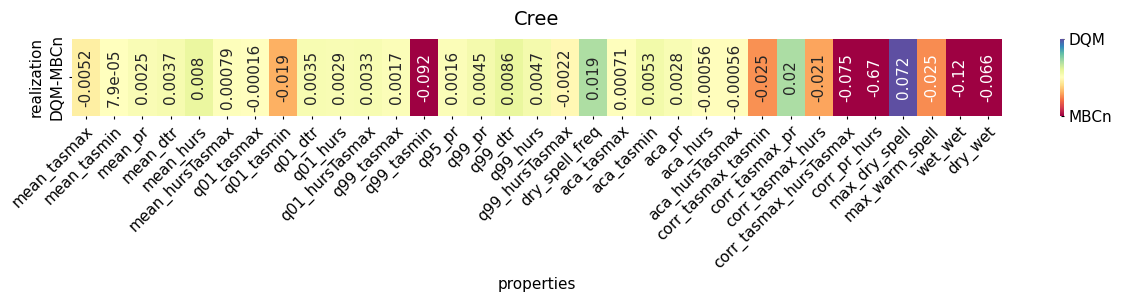

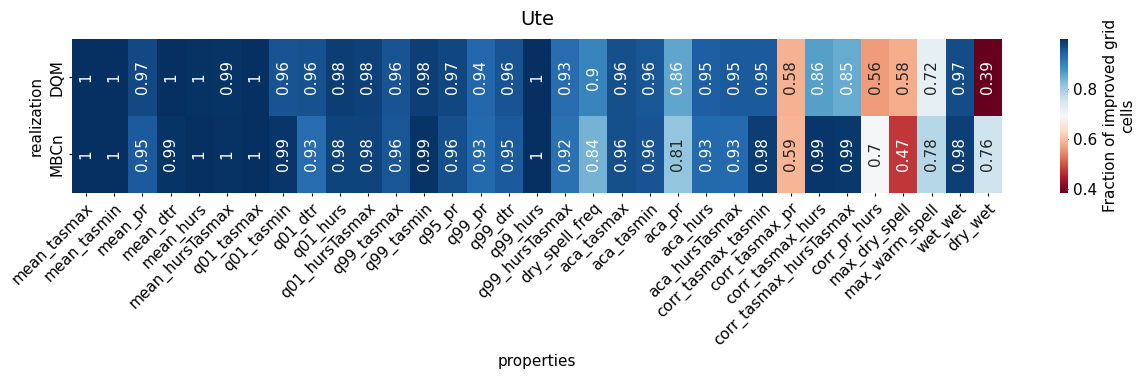

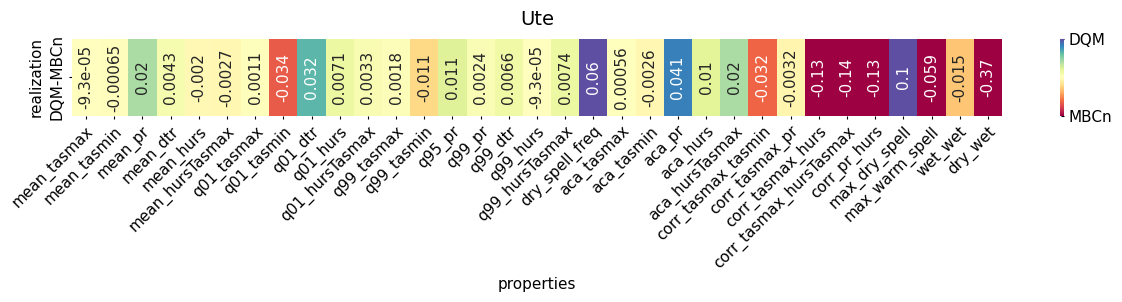

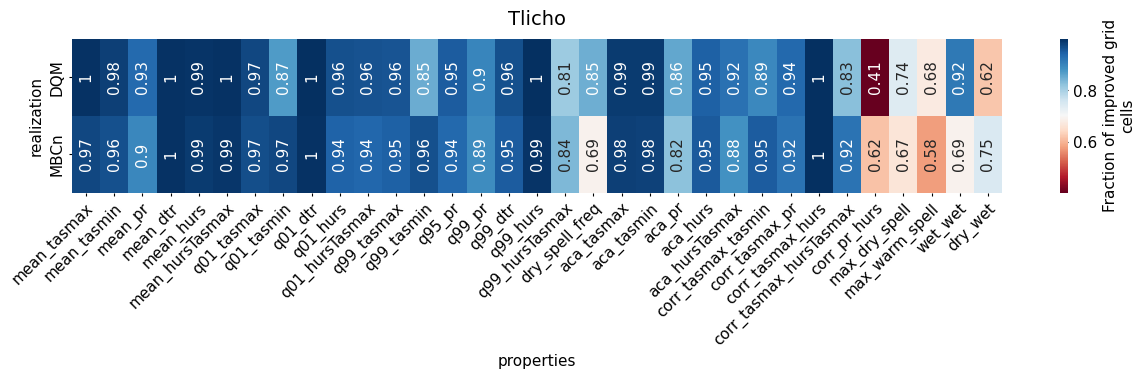

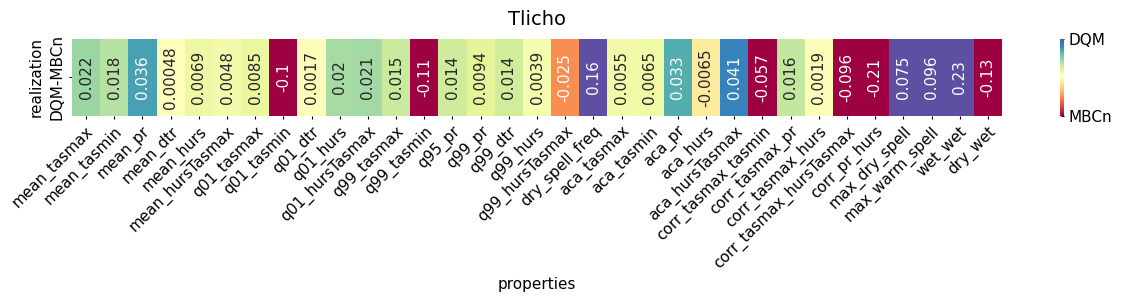

In [28]:
for r in ['Magtogoek','Cree','Ute','Tlicho']:

    imp_dqm=pcat.search(domain=r, bias_adjust_project='DQM', processing_level='imp').to_dataset()
    imp_mbcn=pcat.search(domain=r, bias_adjust_project='MBCn', processing_level='imp').to_dataset()

    #imp_dqm=xr.open_zarr(f'/project/ctb-frigon/julavoie/DQM-test/diagnostics/NAM-E5L/{r}/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_{r}_imp.zarr.zip')
    imp_dqm=imp_dqm.expand_dims(realization=['DQM'])
    #imp_mbcn=xr.open_zarr(f'/project/ctb-frigon/julavoie/MBCn-test/diagnostics/NAM-E5L/{r}/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_{r}_imp.zarr.zip')
    imp_mbcn=imp_mbcn.expand_dims(realization=['MBCn'])
    ds_imp= xr.concat([imp_dqm, imp_mbcn], dim='realization')
    ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_tasmin","q01_dtr","q01_hurs","q01_hursTasmax","q99_tasmax","q99_tasmin","q95_pr","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])

    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, 'annot_kws':{"rotation": 90}}, fig_kw={'figsize':(15,2)})
    ax.set_title(r)

    diff= ds_imp.sel(realization='DQM') - ds_imp.sel(realization='MBCn')
    diff=diff.expand_dims(realization=['DQM-MBCn'])
    #vmin=-abs(diff).max().improved_grid_points.values
    #vmax=abs(diff).max().improved_grid_points.values
    vmin=-0.05
    vmax=0.05
    ax=fg.heatmap(diff,plot_kw={'annot':True, 'annot_kws':{"rotation": 90}, 'vmin':vmin,'vmax':vmax},cmap="Spectral", fig_kw={'figsize':(15,1)})
    ax.figure.axes[1].set_yticks([vmin,vmax], labels=["MBCn", "DQM"])
    ax.set_title(r)
#M: 
#DQM is best for mean_pr

In [39]:
def maps(option_id, option_var):
    "Load properties and measures and plot them."
    
    # get data from catalogue
    prop_sim = pcat.search(id= option_id, processing_level='sim-prop',  variable=option_var).to_dask()
    prop_scen = pcat.search(id= option_id, processing_level='scen-prop',  variable=option_var).to_dask()[option_var]
    meas_sim_prop = pcat.search(id=option_id, processing_level='sim-meas',variable=option_var).to_dask()[option_var]
    meas_scen_prop = pcat.search(id=option_id, processing_level='scen-meas', variable=option_var).to_dask()[option_var]

    prop_ref = pcat.search( processing_level=['ref-prop' ],
                           domain=prop_sim.attrs['cat:domain'], 
                           bias_adjust_project=prop_sim.attrs['cat:bias_adjust_project'],
                           variable=option_var).to_dask()[option_var]
    prop_sim=prop_sim[option_var]

    
    #transpose
    if list(prop_sim.sizes.keys())[0]=='lon':
        prop_ref=prop_ref.transpose()
        prop_sim=prop_sim.transpose()
        prop_scen=prop_scen.transpose()
        meas_sim_prop=meas_sim_prop.transpose()
        meas_scen_prop=meas_scen_prop.transpose()
    
    prop_long_name=prop_sim.attrs['long_name'] 
    meas_long_name=meas_sim_prop.attrs['long_name'] 
    # change units
    if prop_ref.attrs['units']=='kg m-2 s-1':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'mm d-1', context='hydro')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'mm d-1', context='hydro')
        prop_scen = xc.core.units.convert_units_to(prop_scen, 'mm d-1', context='hydro')
        meas_sim_prop = xc.core.units.convert_units_to(meas_sim_prop, 'mm d-1', context='hydro')
        meas_scen_prop = xc.core.units.convert_units_to(meas_scen_prop, 'mm d-1', context='hydro')
        
    if prop_ref.attrs['units']=='K':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'degC')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'degC')
        prop_scen = xc.core.units.convert_units_to(prop_scen, 'degC')
        
    #set colormap
    maxi_prop = max(prop_ref.max().values, prop_scen.max().values, prop_sim.max().values)
    mini_prop = min(prop_ref.min().values, prop_scen.min().values, prop_sim.min().values)
    maxi_meas = float(max(abs(meas_scen_prop).max().values, abs(meas_sim_prop).max().values))

    #plot
    fig = plt.figure(figsize=(15, 8))
    map_proj = ccrs.RotatedPole(pole_longitude=87.59703063964844,
                          pole_latitude=31.758316040039062,
                         )
    gs = gridspec.GridSpec(4, 3)
    ax0= fig.add_subplot(gs[1:3,0],projection=map_proj)
    ax1= fig.add_subplot(gs[:2,1],projection=map_proj)
    ax2= fig.add_subplot(gs[:2,2],projection=map_proj)
    ax3= fig.add_subplot(gs[2:,1],projection=map_proj)
    ax4= fig.add_subplot(gs[2:,2],projection=map_proj)

    plot_kw_prop=dict(add_colorbar=False, vmin=mini_prop,vmax=maxi_prop)
    plot_kw_meas=dict(add_colorbar=False, vmin=-maxi_meas,vmax=maxi_meas)
    features={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
    #plot
    # deep copy until bug is fix TODO
    fg.gridmap(prop_ref, ax=ax0, plot_kw=plot_kw_prop, features=copy.deepcopy(features))
    fg.gridmap(prop_sim, ax=ax1, plot_kw=plot_kw_prop, features=copy.deepcopy(features))
    fg.gridmap(prop_scen, ax=ax3, plot_kw=plot_kw_prop, features=copy.deepcopy(features))
    fg.gridmap(meas_sim_prop, ax=ax2, plot_kw=plot_kw_meas,divergent=True, features=copy.deepcopy(features))
    fg.gridmap(meas_scen_prop, ax=ax4, plot_kw=plot_kw_meas,divergent=True, features=copy.deepcopy(features))

    #prop colorbar
    fig.subplots_adjust(bottom=0.1)
    cbar_ax = fig.add_axes([0.15, 0.01, 0.45, 0.03])
    cb1=fig.colorbar(ax0.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb1.set_label(label=f"{prop_long_name} ({prop_sim.attrs['units']})",size=15)
    cb1.ax.tick_params(axis='x', direction='out')
    cb1.outline.set_visible(False)
    
    #meas colorbar
    fig.subplots_adjust(bottom=0.1)
    cbar_ax = fig.add_axes([0.68, 0.01, 0.25, 0.03])
    cb2=fig.colorbar(ax2.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb2.set_label(label=f"{meas_long_name} ({meas_sim_prop.attrs['units']})",size=15)
    
    cb2.ax.tick_params(axis='x', direction='out')
    cb2.outline.set_visible(False)


    rmse_sim= np.sqrt(np.nanmean((
        prop_sim.stack(loc=['lat','lon']).values  -
        prop_ref.stack(loc=['lat','lon']).values) ** 2))

    rmse_scen= np.sqrt(np.nanmean((
        prop_scen.stack(loc=['lat','lon']).values  -
        prop_ref.stack(loc=['lat','lon']).values) ** 2))
    
    
    fs=15
    ax0.set_title(r'a) reference', fontsize=fs)
    ax1.set_title(r'b) original', fontsize=fs)
    prop_sim.attrs['units']=prop_sim.attrs['units'].replace('mm d-1', 'mm/d')
    prop_scen.attrs['units']=prop_scen.attrs['units'].replace('mm d-1', 'mm/d')
    ax2.set_title(f"c) original \n RMSE={rmse_sim:.2f} {prop_sim.attrs['units']}",fontsize=fs)
    #ax2.set_title(f"c) original",fontsize=fs)

    ax3.set_title(r'd) bias-adjusted', fontsize=fs)
    ax4.set_title(f"e) bias-adjusted \n RMSE={rmse_scen:.2f} {prop_scen.attrs['units']}",fontsize=fs)
    #ax4.set_title(f"e) bias-adjusted",fontsize=fs)
    fig.tight_layout(pad=5.0)
    return fig,[ax0,ax1,ax2,ax3,ax4], [cb1,cb2]

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/tmp/ipykernel_597845/3931495689.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/fig

(<Figure size 1500x800 with 7 Axes>,
 [<GeoAxes: title={'center': 'a) reference'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
  <GeoAxes: title={'center': 'b) original'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
  <GeoAxes: title={'center': 'c) original \n RMSE=0.37 mm/d'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
  <GeoAxes: title={'center': 'd) bias-adjusted'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
  <GeoAxes: title={'center': 'e) bias-adjusted \n RMSE=0.03 mm/d'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>],
  <matplotlib.colorbar.Colorbar at 0x14e9e0a34e90>])

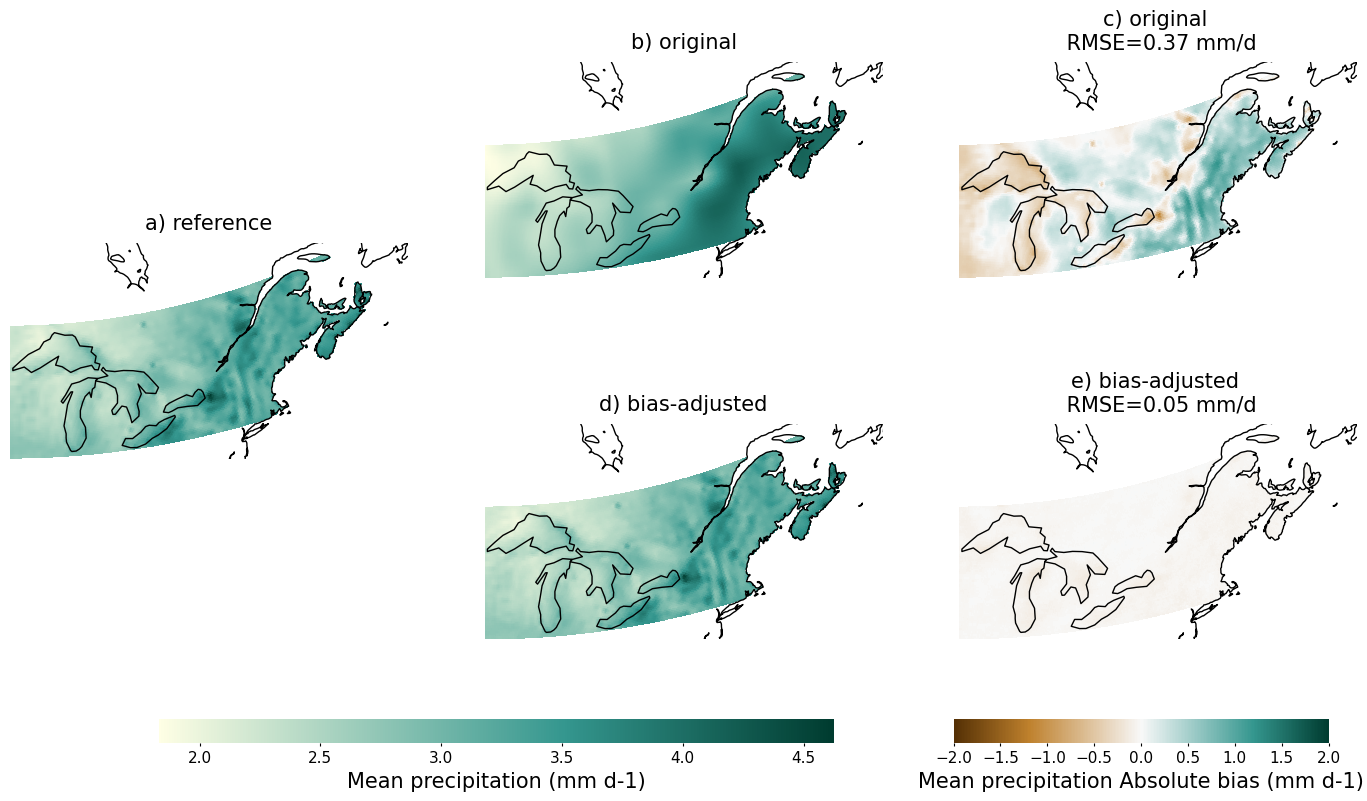

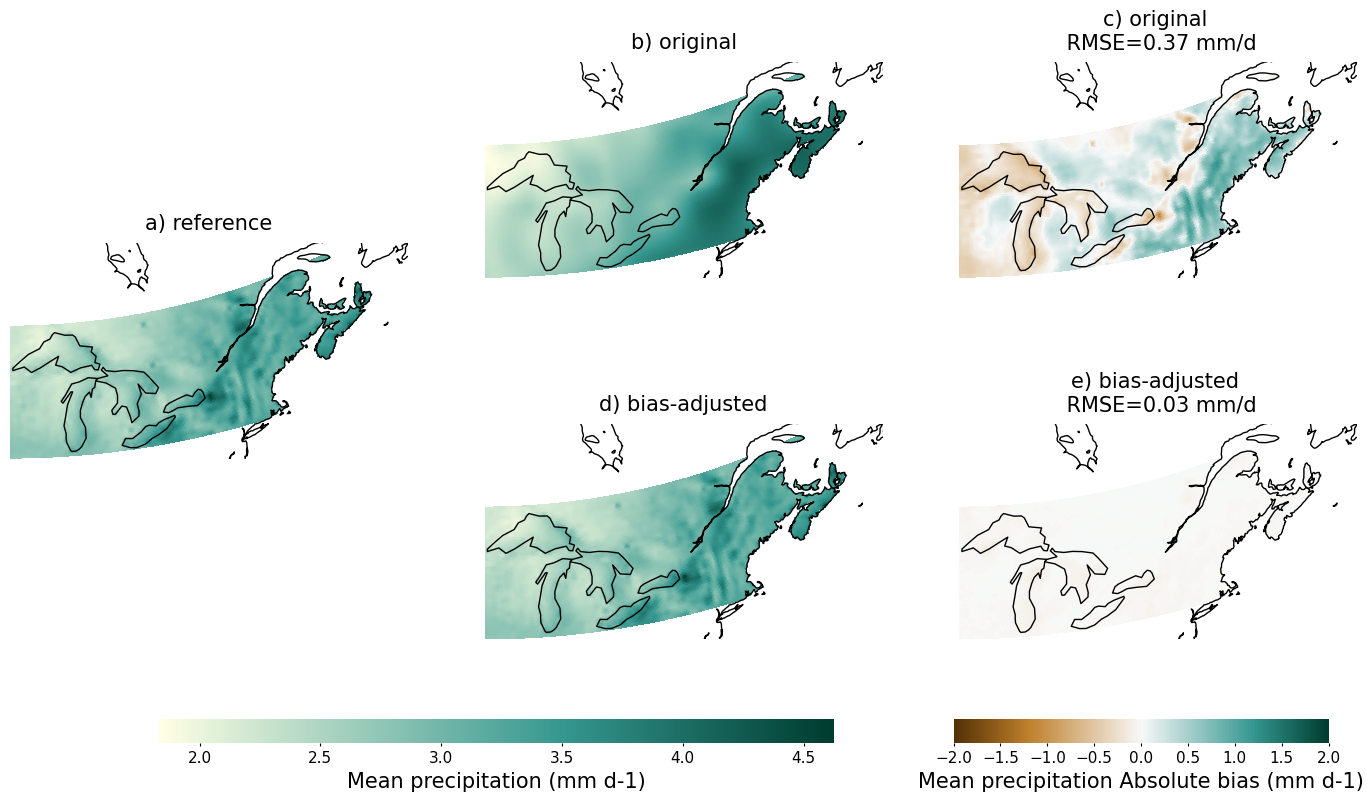

In [22]:

maps('MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek', 'mean_pr')
maps('DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek', 'mean_pr')

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.


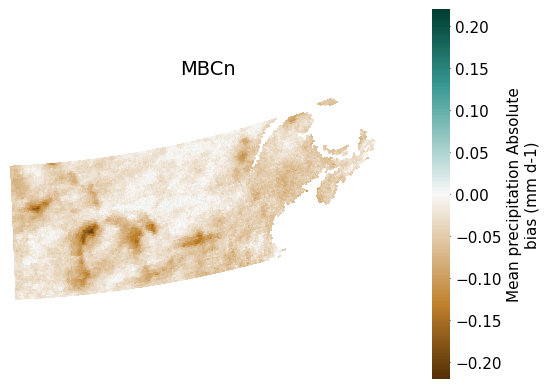

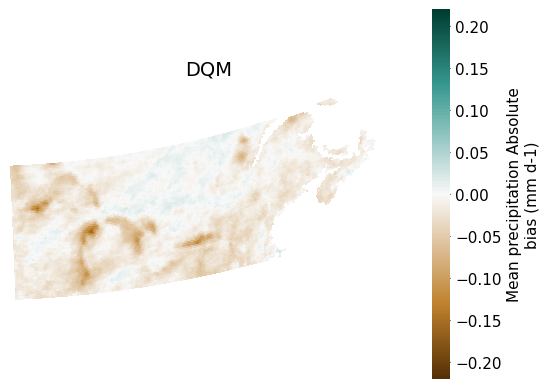

In [27]:
option_var='mean_pr'
for option_id in ['MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek',
          'DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek']:
    meas_scen_prop = pcat.search(id=option_id, processing_level='scen-meas', variable=option_var).to_dask()[option_var]
    ax=fg.gridmap(meas_scen_prop, plot_kw=dict(vmin=-0.22, vmax=0.22), cmap='prec_div')
    ax.set_title(option_id.split('_')[0])

# spell

In [38]:
list(prop_simM.sizes.keys())[0]

'lat'

In [21]:
option_id='MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek'
option_var="max_warm_spell"
prop_simM= pcat.search(id= option_id, processing_level='sim-prop',  variable=option_var).to_dask()
display(prop_simM)
print(list(prop_simM.dims.keys())[0]
option_id='DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek'
prop_simD= pcat.search(id= option_id, processing_level='sim-prop',  variable=option_var).to_dask()
display(prop_simD)

<xarray.Dataset> Size: 107kB
Dimensions:         (lat: 81, lon: 325)
Coordinates:
  * lat             (lat) float32 324B 41.4 41.5 41.6 41.7 ... 49.2 49.3 49.4
  * lon             (lon) float32 1kB -92.2 -92.1 -92.0 ... -60.0 -59.9 -59.8
Data variables:
    max_warm_spell  (lat, lon) float32 105kB dask.array<chunksize=(81, 325), meta=np.ndarray>
Attributes: (12/75)
    CMIP6_CV_version:         cv=6.2.3.0-7-g2019642
    Conventions:              CF-1.7 CMIP-6.2
    EXPID:                    CNRM-CM6-1_historical_r1i1p1f2
    NCO:                      "4.5.5"
    activity_id:              CMIP
    arpege_minor_version:     6.3.2
    ...                       ...
    tracking_id:              hdl:21.14100/404d17a6-e9d7-43e7-9d93-e2ddc57979a9
    variable_id:              tasmax
    variant_label:            r1i1p1f2
    xios_commit:              1442-shuffle
    cat:bias_adjust_project:  MBCn
    cat:variable:             aca_hurs,aca_hursTasmax,aca_pr,aca_tasmax,aca_t...

<xarray.Dataset> Size: 107kB
Dimensions:         (lon: 325, lat: 81)
Coordinates:
  * lat             (lat) float32 324B 41.4 41.5 41.6 41.7 ... 49.2 49.3 49.4
  * lon             (lon) float32 1kB -92.2 -92.1 -92.0 ... -60.0 -59.9 -59.8
Data variables:
    max_warm_spell  (lon, lat) float32 105kB dask.array<chunksize=(325, 81), meta=np.ndarray>
Attributes: (12/75)
    CMIP6_CV_version:         cv=6.2.3.0-7-g2019642
    Conventions:              CF-1.7 CMIP-6.2
    EXPID:                    CNRM-CM6-1_historical_r1i1p1f2
    NCO:                      "4.5.5"
    activity_id:              CMIP
    arpege_minor_version:     6.3.2
    ...                       ...
    tracking_id:              hdl:21.14100/404d17a6-e9d7-43e7-9d93-e2ddc57979a9
    variable_id:              tasmax
    variant_label:            r1i1p1f2
    xios_commit:              1442-shuffle
    cat:bias_adjust_project:  DQM
    cat:variable:             aca_hurs,aca_hursTasmax,aca_pr,aca_tasmax,aca_t...

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/tmp/ipykernel_2912792/3486791957.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/fi

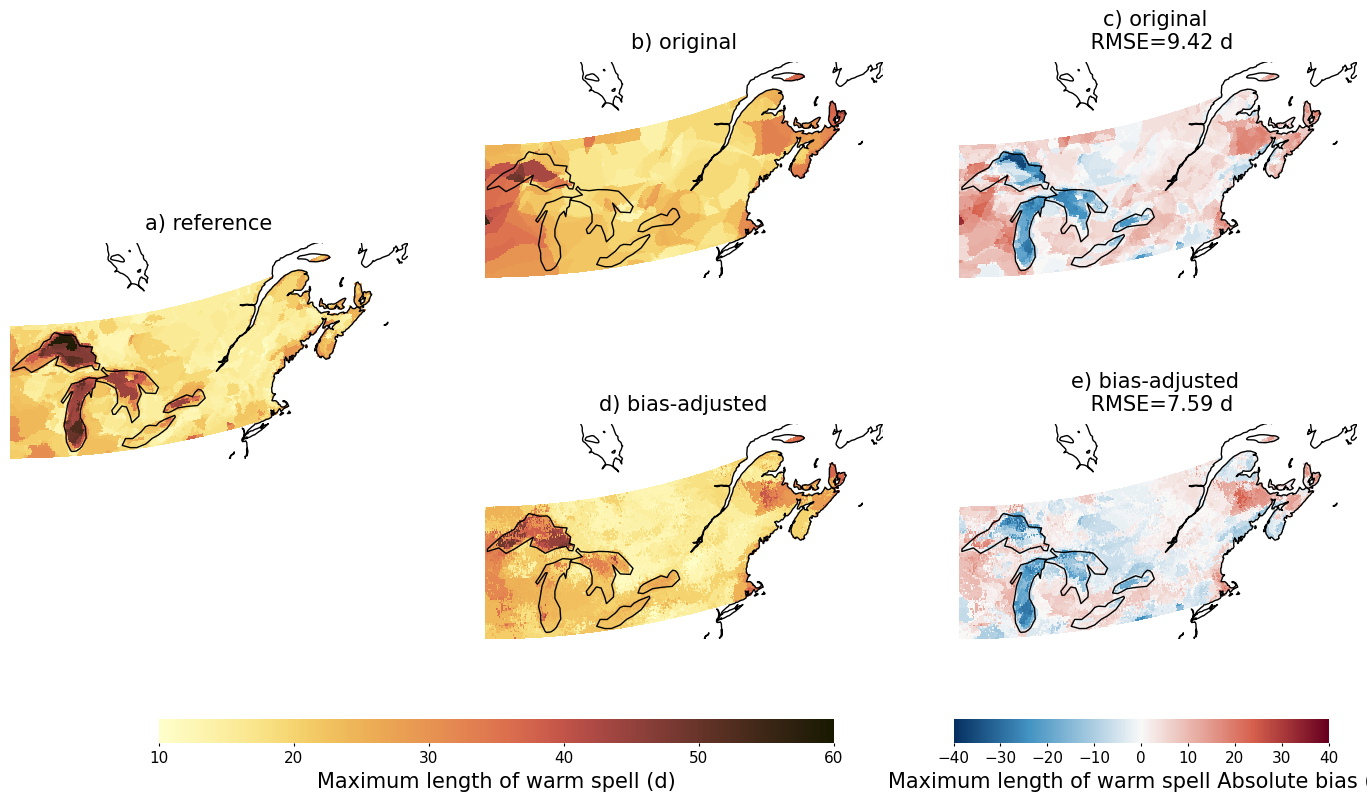

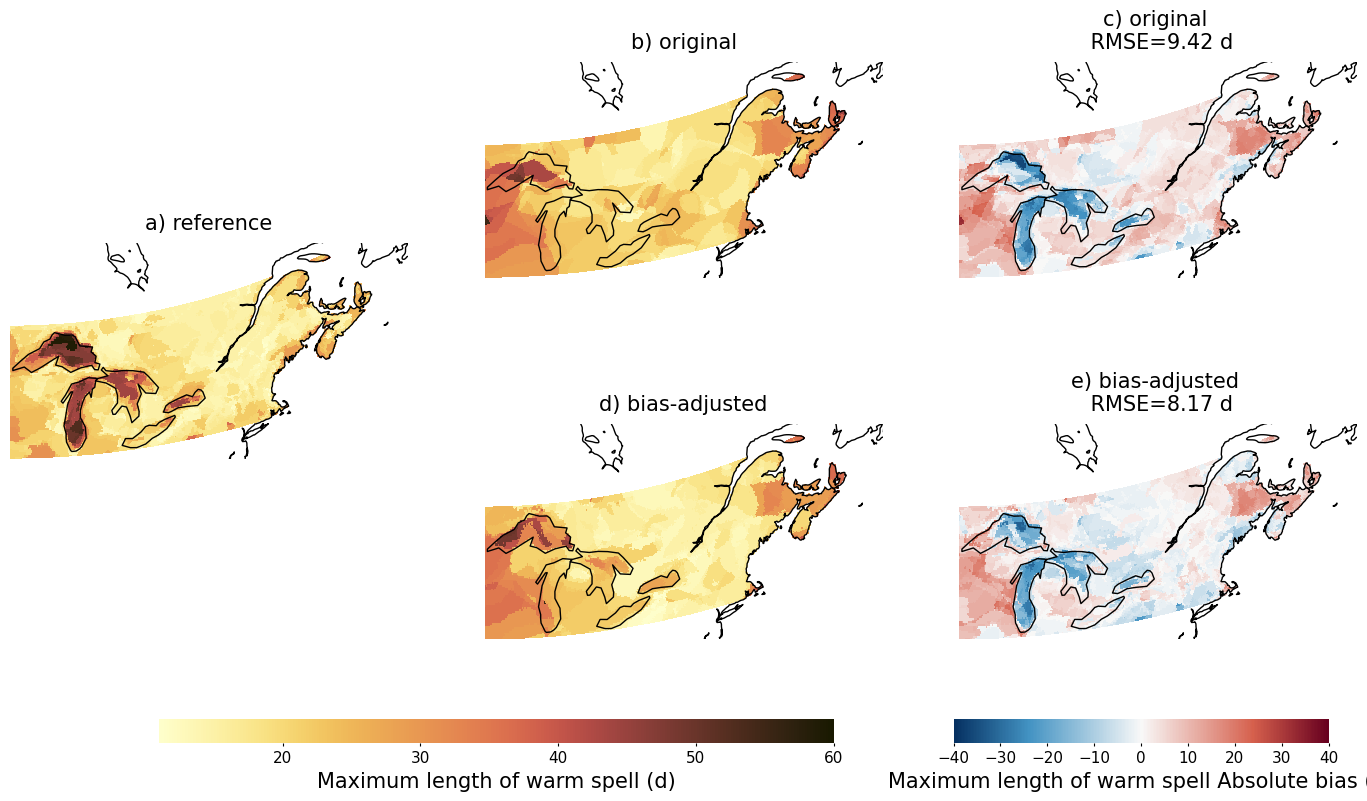

In [40]:
maps('MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek', "max_warm_spell");
maps('DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_Magtogoek', "max_warm_spell");

# delta

In [23]:


ds_mbcn=xr.open_mfdataset(glob.glob('/project/ctb-frigon/julavoie/MBCn-test/staging/simulation/biasadjusted/MBCn-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/*/*_day_MBCn_v10_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_1951-2100.zarr.zip'), engine='zarr')
ds_dqm=xr.open_mfdataset(glob.glob('/project/ctb-frigon/julavoie/DQM-test/staging/simulation/biasadjusted/ESPO-G6-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/*/*_day_DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_1951-2100.zarr.zip'), engine='zarr')

ds_reg=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global+NAM-E5L+middleE5L+regchunked.zarr')
ds_reg=ds_reg.rename({'hursmin': 'hursTasmax'})
for var in ['tasmax', 'tasmin', 'pr','hurs', 'hursTasmax']:
#for var in [ 'tasmin']:


    dmbcn=xs.spatial.subset(ds_mbcn,method='gridpoint',lat= 45.5,lon=-73.5)
    dmbcn=dmbcn[var].resample(time='YS').mean()
    dmbcn=dmbcn - dmbcn.sel(time=slice('1990','2021')).mean(dim='time')


    ddqm=xs.spatial.subset(ds_dqm,method='gridpoint',lat= 45.5,lon=-73.5)
    ddqm=ddqm[var].resample(time='YS').mean()
    ddqm=ddqm - ddqm.sel(time=slice('1990','2021')).mean(dim='time')

    dreg=xs.spatial.subset(ds_reg,method='gridpoint',lat= 45.5,lon=-73.5)
    dreg=dreg[var].resample(time='YS').mean()
    dreg=dreg - dreg.sel(time=slice('1990','2021')).mean(dim='time')

    
    ax=fg.timeseries({'MBCn': dmbcn, 'DQM':ddqm,'regridded':dreg})
    ax.set_title(var)

FileNotFoundError: No such file or directory: '/scratch/julavoie/espo-workdir/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global+NAM-E5L+middleE5L+regchunked.zarr'

In [ ]:
import random

ds_mbcn=xr.open_mfdataset(glob.glob('/project/ctb-frigon/julavoie/MBCn-test/staging/simulation/biasadjusted/MBCn-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/*/*_day_MBCn_v10_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_1951-2100.zarr.zip'), engine='zarr')
ds_dqm=xr.open_mfdataset(glob.glob('/project/ctb-frigon/julavoie/DQM-test/staging/simulation/biasadjusted/ESPO-G6-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/*/*_day_DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global_NAM-E5L_1951-2100.zarr.zip'), engine='zarr')

ds_reg=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_ssp370_r1i1p1f2_global+NAM-E5L+middleE5L+regchunked.zarr')
ds_reg=ds_reg.rename({'hursmin': 'hursTasmax'})

points=[]

for var in ['tasmax', 'tasmin', 'pr','hurs', 'hursTasmax']:
    fig, ax= plt.subplots(figsize=(15,5))
    for i in range(10):
        print(i)
        # find non-nan point
        p =(round(random.uniform(-179.95, -10 ),2),round(random.uniform(40.05, 65.05  ),2))
        dmbcn=xs.spatial.subset(ds_mbcn,method='gridpoint',lat= p[1],lon=p[0])
        while dmbcn.tasmax.isnull().any():
            p =(round(random.uniform(-179.95, -10 ),2),round(random.uniform(40.05, 65.05 ),2))
            dmbcn=xs.spatial.subset(ds_mbcn,method='gridpoint',lat= p[1],lon=p[0])
        points.append(p)
        
        
        dmbcn=dmbcn[var].resample(time='YS').mean()
        dmbcn=(dmbcn.sel(time=slice('2071','2100')).mean(dim='time')) - (dmbcn.sel(time=slice('1990','2021')).mean(dim='time'))
        plt.bar(i-0.2, dmbcn.values, label='MBCn',width=0.1, color='red')
    
    
        dreg=xs.spatial.subset(ds_reg,method='gridpoint',lat= p[1],lon=p[0])
        dreg=dreg[var].resample(time='YS').mean()
        dreg=dreg.sel(time=slice('2071','2100')).mean(dim='time') - dreg.sel(time=slice('1990','2021')).mean(dim='time')
        plt.bar(i, dreg.values, label='reg',width=0.1, color='yellow')

        ddqm=xs.spatial.subset(ds_dqm,method='gridpoint',lat= p[1],lon=p[0])
        ddqm=ddqm[var].resample(time='YS').mean()
        ddqm=ddqm.sel(time=slice('2071','2100')).mean(dim='time') - ddqm.sel(time=slice('1990','2021')).mean(dim='time')
        plt.bar(i+0.2, ddqm.values, label='DQM',width=0.1, color='blue')

    ax.set_title(var)
    ax.set_xticklabels(points)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# humidex

In [60]:
# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir']}/staging/simulation/biasadjusted/MBCn-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/',
#                  f'{CONFIG['paths']['finaldir'].replace('MBCn-test', 'DQM-test')}/staging/simulation/biasadjusted/ESPO-G6-E5L_v10/CMIP6/ScenarioMIP/NAM-E5L/CNRM-CERFACS/CNRM-CM6-1/ssp370/r1i1p1f2/day/',
# ],
#     patterns=[
#         '{variable}/{variable}_{frequency}_{bias_adjust_project}_{version}_{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_{domain}_{DATES}.zarr.zip',
#         '{variable}/{variable}_{frequency}_{bias_adjust_project}_{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_{domain}_{DATES}.zarr.zip'

#     ],
#     homogenous_info={
#         "processing_level":'biasadjusted'
#     },
# );
# display(df)                                                                                                            
# pcat.update(df)
# df = xs.parse_directory(
#     directories=[f'{CONFIG['paths']['finaldir']}/reference/',
# ],
#     patterns=[
#         '{domain}_default.zarr.zip',
#     ],
#     homogenous_info={
#         "source": "ERA5-Land",
#         "processing_level":'raw'
#     },
#     read_from_file=["variable","date_start","date_end"],
# );
# display(df)
# pcat.update(df)

2025-07-08 15:43:20 INFO     xscen.catutils  Found and parsed 12 files.


,id,type,processing_level,bias_adjust_institution,bias_adjust_project,mip_era,activity,driving_model,driving_member,institution,...,member,xrfreq,frequency,variable,domain,date_start,date_end,version,format,path
0,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,tasmin,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
1,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,pr,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
2,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,hurs,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
3,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,hursTasmax,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
4,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,dtr,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
5,MBCn_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1...,None,biasadjusted,None,MBCn,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,tasmax,NAM-E5L,1951-01-01,2100-12-31 23:59:59,v10,zarr,/project/ctb-frigon/julavoie/MBCn-test/staging...
6,DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_...,None,biasadjusted,None,DQM,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,tasmax,NAM-E5L,1951-01-01,2100-12-31 23:59:59,NaN,zarr,/project/ctb-frigon/julavoie/DQM-test/staging/...
7,DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_...,None,biasadjusted,None,DQM,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,hursTasmax,NAM-E5L,1951-01-01,2100-12-31 23:59:59,NaN,zarr,/project/ctb-frigon/julavoie/DQM-test/staging/...
8,DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_...,None,biasadjusted,None,DQM,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,dtr,NAM-E5L,1951-01-01,2100-12-31 23:59:59,NaN,zarr,/project/ctb-frigon/julavoie/DQM-test/staging/...
9,DQM_CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-CM6-1_...,None,biasadjusted,None,DQM,CMIP6,ScenarioMIP,None,None,CNRM-CERFACS,...,r1i1p1f2,D,day,pr,NAM-E5L,1951-01-01,2100-12-31 23:59:59,NaN,zarr,/project/ctb-frigon/julavoie/DQM-test/staging/...


2025-07-08 15:43:21 INFO     xscen.catutils  Parsing attributes with xarray from /project/ctb-frigon/julavoie/MBCn-test/reference/NAM-E5L_default.zarr.zip.
2025-07-08 15:43:21 INFO     xscen.catutils  Found and parsed 1 files.


,id,type,processing_level,bias_adjust_institution,bias_adjust_project,mip_era,activity,driving_model,driving_member,institution,...,member,xrfreq,frequency,variable,domain,date_start,date_end,version,format,path
0,ERA5-Land_NAM-E5L,None,raw,None,None,None,None,None,None,None,...,None,<NA>,<NA>,"(dtr, hurs, hursTasmax, pr, tasmax, tasmin)",NAM-E5L,1991-01-01,2020-12-31,None,zarr,/project/ctb-frigon/julavoie/MBCn-test/referen...


/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/s

Text(0.5, 1.0, 'DQM - MBCn')

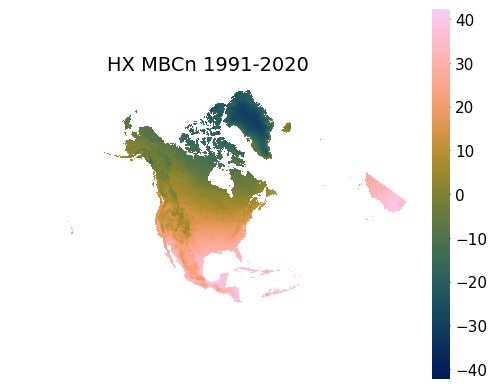

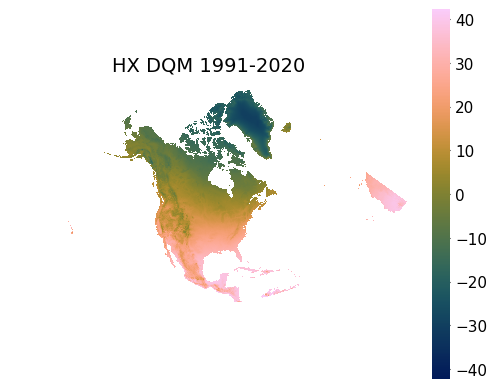

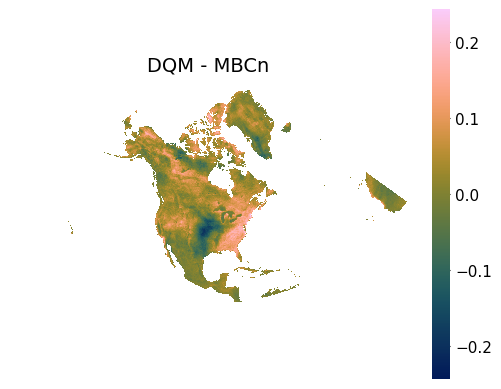

In [3]:
hx_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx').to_dataset()
hx_dqm=pcat.search(bias_adjust_project='DQM',variable='hx').to_dataset()
hx_ref=pcat.search(source='ERA5-Land',variable='hx').to_dataset()

hx_mbcn=hx_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1))
hx_dqm=hx_dqm.sel(time=slice('1991','2020'))
hx_ref=hx_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1))

hx_mbcn=hx_mbcn.hx.chunk({'time':-1})
hx_dqm=hx_dqm.hx.chunk({'time':-1})
hx_ref=hx_ref.hx.chunk({'time':-1})

ax=fg.gridmap(hx_mbcn.mean(dim='time'))
ax.set_title('HX MBCn 1991-2020')
ax=fg.gridmap(hx_dqm.mean(dim='time'))
ax.set_title('HX DQM 1991-2020')

ax=fg.gridmap(hx_dqm.mean(dim='time')-hx_mbcn.mean(dim='time'))
ax.set_title('DQM - MBCn')

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/pyth

Text(0.5, 1.0, 'DQM-MBCn hx')

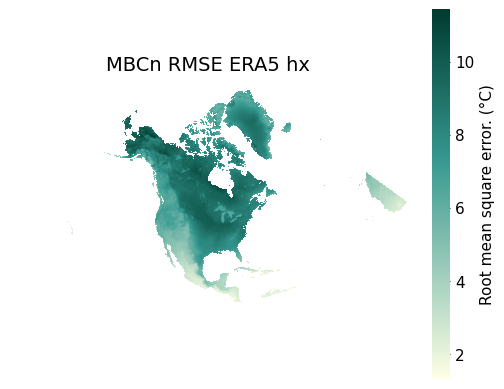

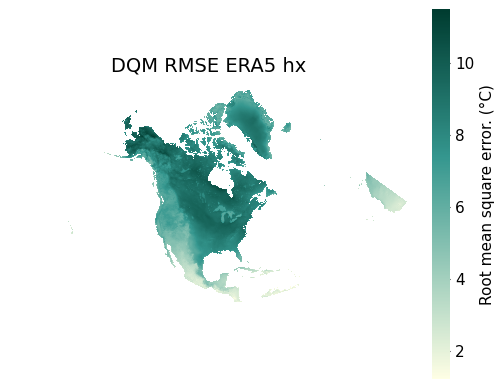

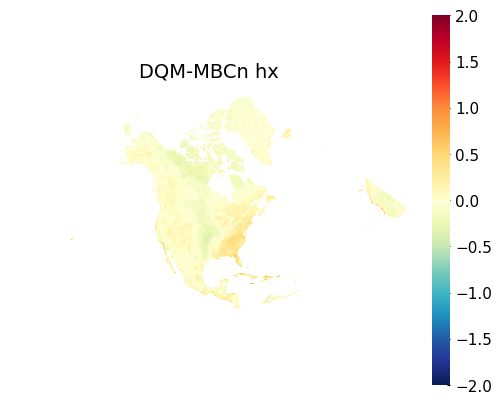

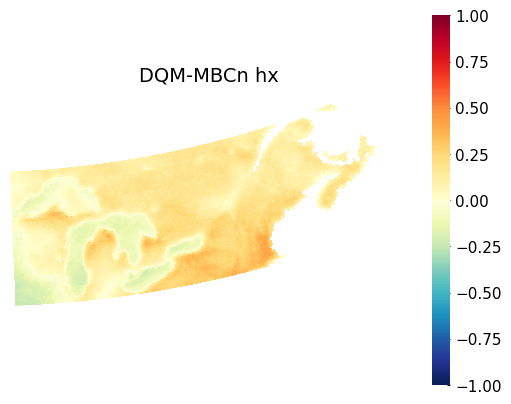

In [4]:
#rmse





rmse_mbcn= xa.measures.rmse(hx_mbcn, hx_ref)
rmse_dqm= xa.measures.rmse(hx_dqm, hx_ref)

ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
ax.set_title('MBCn RMSE ERA5 hx')

ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
ax.set_title('DQM RMSE ERA5 hx')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-2, 'vmax':2})
ax.set_title('DQM-MBCn hx')

diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-0.5, 'vmax':0.5})
ax.set_title('DQM-MBCn hx')

## HX35

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/pyth

Text(0.5, 1.0, 'DQM-MBCn HX35 RMSE')

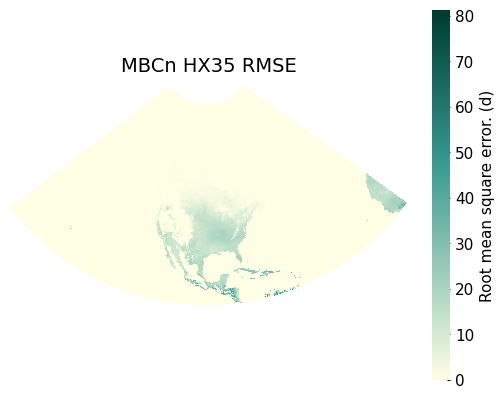

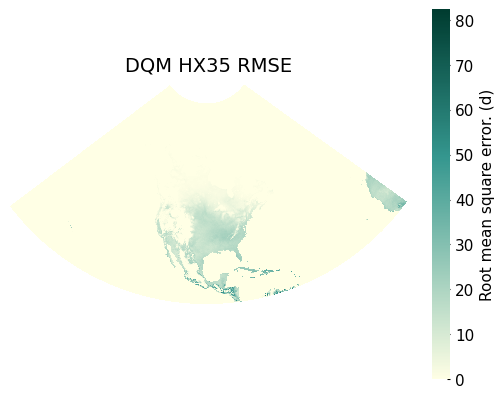

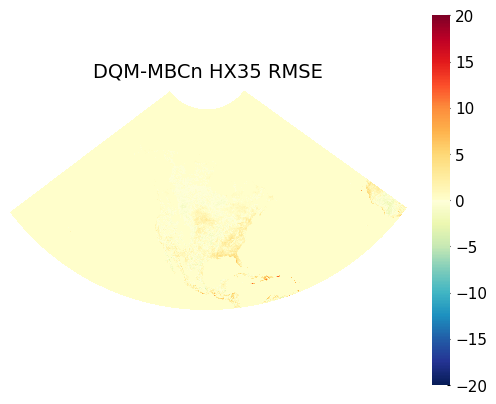

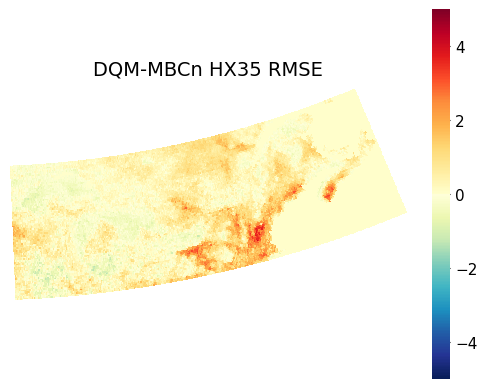

In [5]:
hx35_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx35').to_dataset().hx35
hx35_dqm=pcat.search(bias_adjust_project='DQM',variable='hx35').to_dataset().hx35
hx35_ref=pcat.search(source='ERA5-Land',variable='hx35').to_dataset().hx35

hx35_mbcn=hx35_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})
hx35_dqm=hx35_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
hx35_ref=hx35_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})


rmse_mbcn= xa.measures.rmse(hx35_mbcn, hx35_ref)
rmse_dqm= xa.measures.rmse(hx35_dqm, hx35_ref)

ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
ax.set_title('MBCn HX35 RMSE')

ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
ax.set_title('DQM HX35 RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-18, 'vmax':18})
ax.set_title('DQM-MBCn HX35 RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-5, 'vmax':5})
ax.set_title('DQM-MBCn HX35 RMSE')


/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/s

Text(0.5, 1.0, 'DQM-MBCn HX30 RMSE')

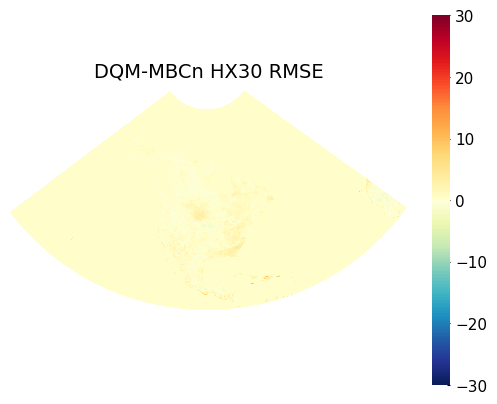

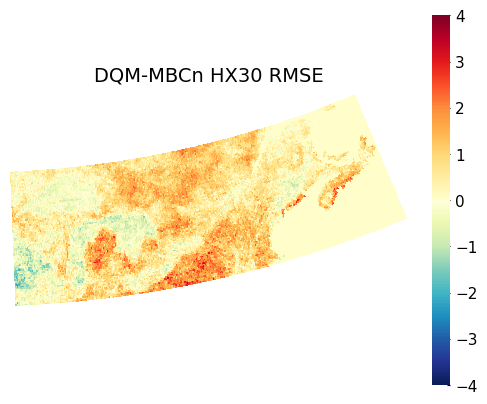

In [6]:
hx30_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx30').to_dataset().hx30
hx30_dqm=pcat.search(bias_adjust_project='DQM',variable='hx30').to_dataset().hx30
hx30_ref=pcat.search(source='ERA5-Land',variable='hx30').to_dataset().hx30

hx30_mbcn=hx30_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})
hx30_dqm=hx30_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
hx30_ref=hx30_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})


rmse_mbcn= xa.measures.rmse(hx30_mbcn, hx30_ref)
rmse_dqm= xa.measures.rmse(hx30_dqm, hx30_ref)

# ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
# ax.set_title('MBCn HX30 RMSE')

# ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
# ax.set_title('DQM HX30 RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-30, 'vmax':30})
ax.set_title('DQM-MBCn HX30 RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-4, 'vmax':4})
ax.set_title('DQM-MBCn HX30 RMSE')


## thi

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/s

Text(0.5, 1.0, 'DQM-MBCn thi RMSE')

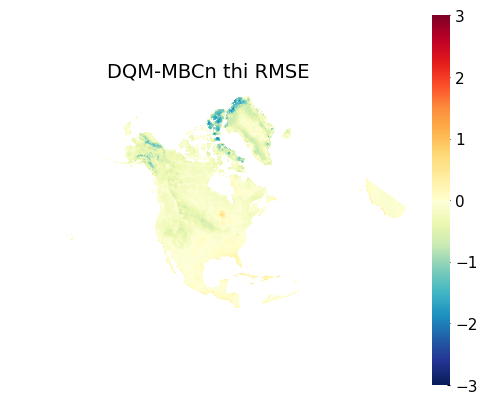

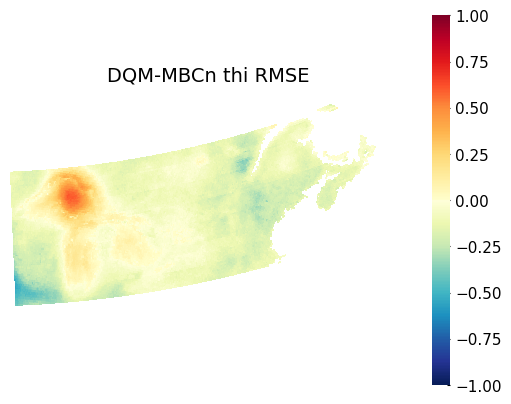

In [10]:
thi_mbcn=pcat.search(bias_adjust_project='MBCn',variable='thi').to_dataset().thi
thi_dqm=pcat.search(bias_adjust_project='DQM',variable='thi').to_dataset().thi
thi_ref=pcat.search(source='ERA5-Land',variable='thi').to_dataset().thi

thi_mbcn=thi_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})
thi_dqm=thi_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
thi_ref=thi_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})


rmse_mbcn= xa.measures.rmse(thi_mbcn, thi_ref)
rmse_dqm= xa.measures.rmse(thi_dqm, thi_ref)

# ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
# ax.set_title('MBCn thi RMSE')

# ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
# ax.set_title('DQM thi RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-3, 'vmax':3})
ax.set_title('DQM-MBCn thi RMSE')

diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-1, 'vmax':1})
ax.set_title('DQM-MBCn thi RMSE')

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/pyth

Text(0.5, 1.0, 'DQM-MBCn this RMSE')

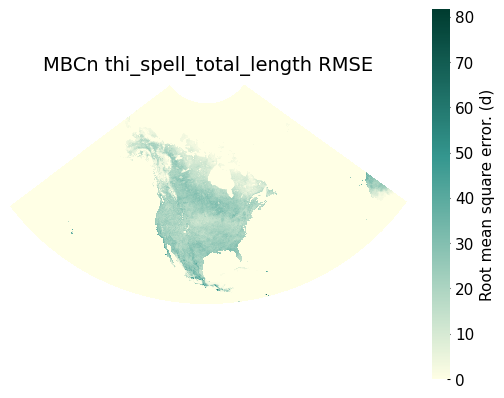

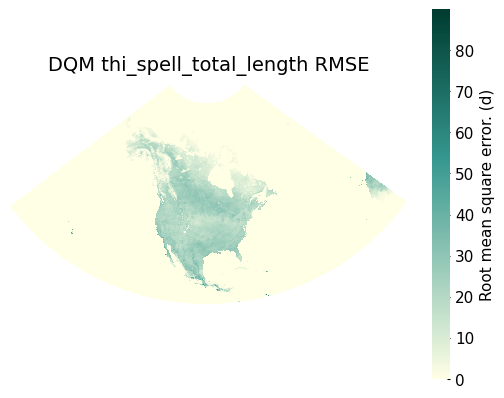

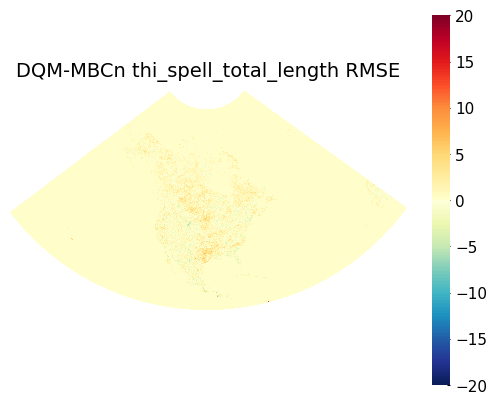

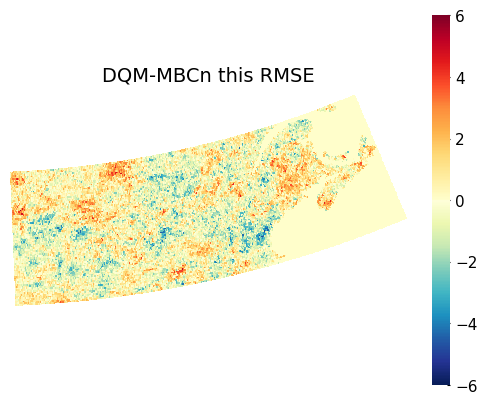

In [11]:
this_mbcn=pcat.search(bias_adjust_project='MBCn',variable='thi_spell_total_length').to_dataset().thi_spell_total_length
this_dqm=pcat.search(bias_adjust_project='DQM',variable='thi_spell_total_length').to_dataset().thi_spell_total_length
this_ref=pcat.search(source='ERA5-Land',variable='thi_spell_total_length').to_dataset().thi_spell_total_length

this_mbcn=this_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})
this_dqm=this_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
this_ref=this_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})


rmse_mbcn= xa.measures.rmse(this_mbcn, this_ref)
rmse_dqm= xa.measures.rmse(this_dqm, this_ref)

ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
ax.set_title('MBCn thi_spell_total_length RMSE')

ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
ax.set_title('DQM thi_spell_total_length RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-15, 'vmax':15})
ax.set_title('DQM-MBCn thi_spell_total_length RMSE')

diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-6, 'vmax':6})
ax.set_title('DQM-MBCn this RMSE')

In [19]:
imp

<xarray.Dataset> Size: 16B
Dimensions:               (properties: 1)
Coordinates:
  * properties            (properties) object 8B 'bias'
Data variables:
    improved_grid_points  (properties) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    cat:processing_level:  diag-improved

## dist

0
1
2
3
4
5
6
7
8
9


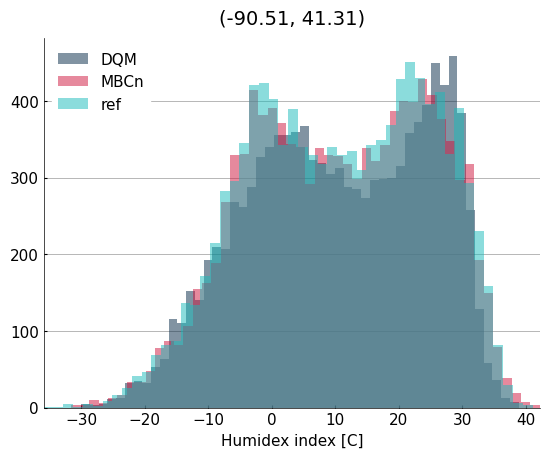

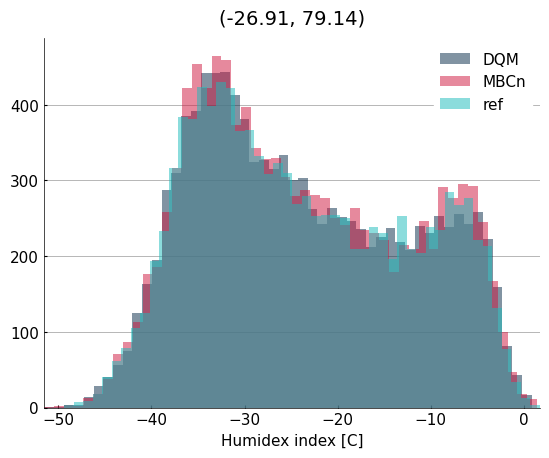

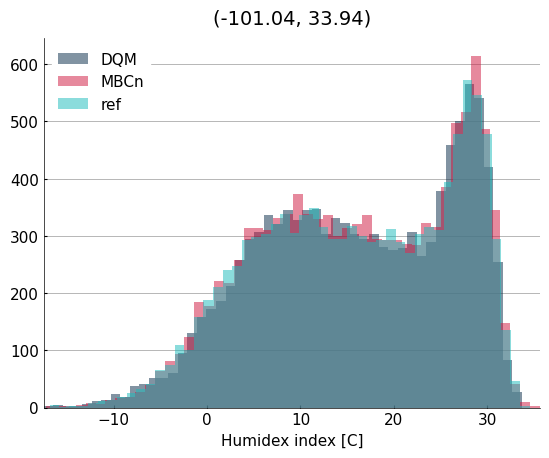

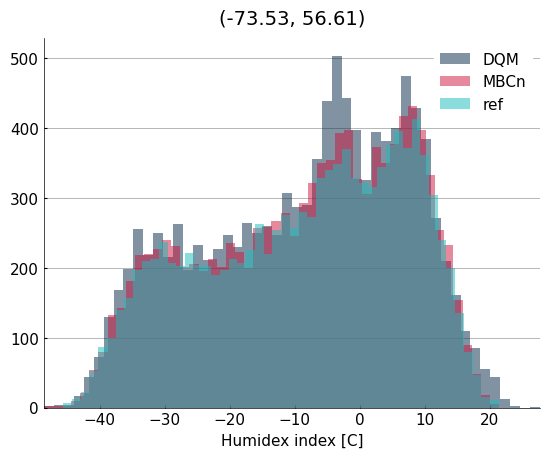

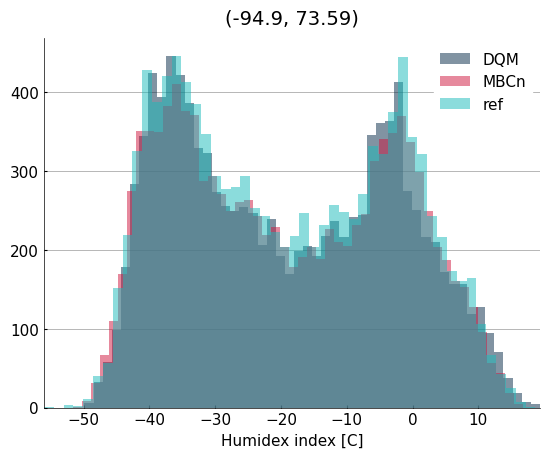

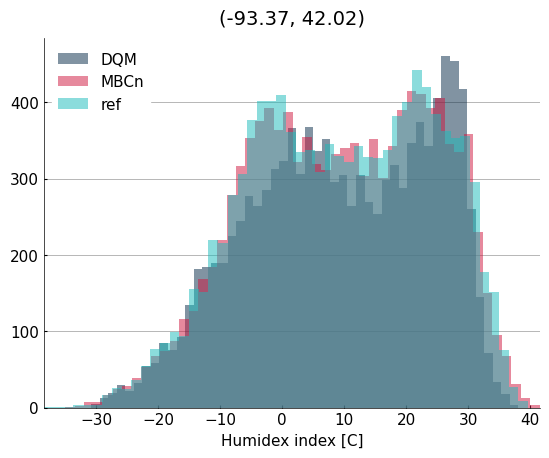

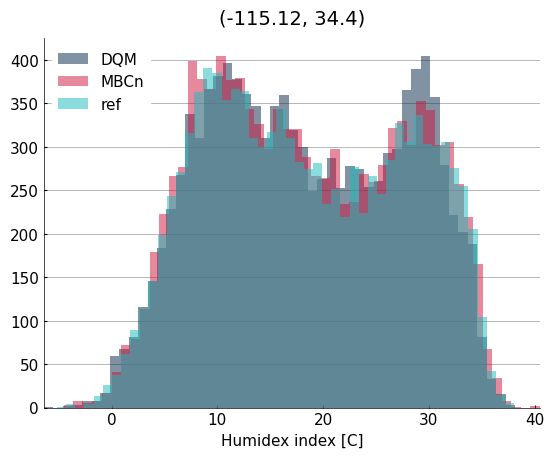

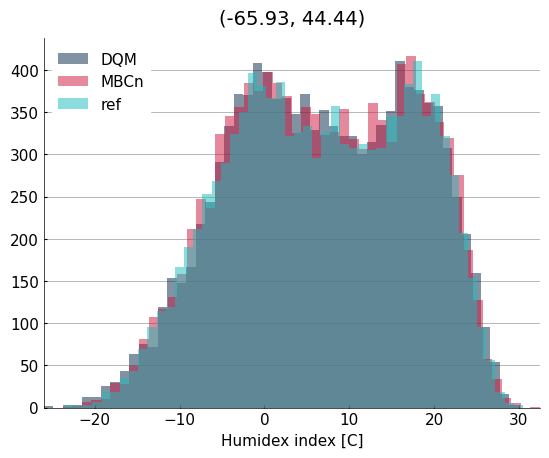

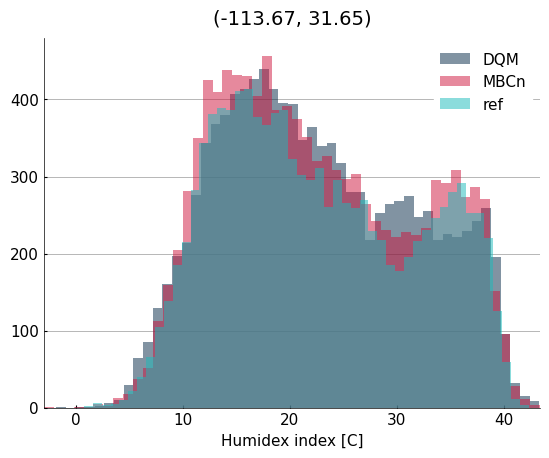

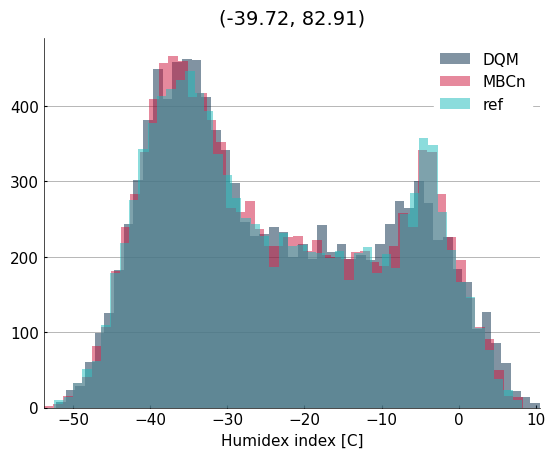

In [40]:
# random point and random year
import random
for i in range(10):
    print(i)
    # find non-nan point
    p =(round(random.uniform(-179.95, -10 ),2),round(random.uniform(10,83.4  ),2))
    
    hx_mbcn_p=xs.spatial.subset(hx_mbcn,method='gridpoint',lat= p[1],lon=p[0])
    while hx_mbcn_p.isnull().any():
            p =(round(random.uniform(-179.95, -10 ),2),round(random.uniform(10,83.4 ),2))
            hx_mbcn_p=xs.spatial.subset(hx_mbcn,method='gridpoint',lat= p[1],lon=p[0])

    
    hx_dqm_p=xs.spatial.subset(hx_dqm,method='gridpoint',lat= p[1],lon=p[0])
    hx_ref_p=xs.spatial.subset(hx_ref,method='gridpoint',lat= p[1],lon=p[0])

    plt.figure()
    hx_dqm_p.plot.hist(label='DQM', alpha=0.5, bins=50)
    hx_mbcn_p.plot.hist(label='MBCn', alpha=0.5, bins=50)
    hx_ref_p.plot.hist(label='ref', alpha=0.5, bins=50)
    plt.title(p)
    plt.legend()

In [ ]:
# guillaume recommande à froid, univarié + ajust l'indicateur.

# solid_prcptot

/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:879: UserWarning: Colormap warning: Variable group not found. Use the cmap argument.
/lustre06/project/6046550/julavoie/envs/dqm/lib/python3.12/site-packages/figanos/matplotlib/utils.py:228: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm/lib/pyth

Text(0.5, 1.0, 'DQM-MBCn solid pr RMSE')

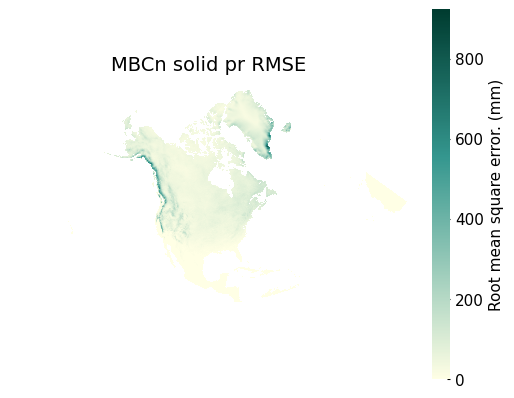

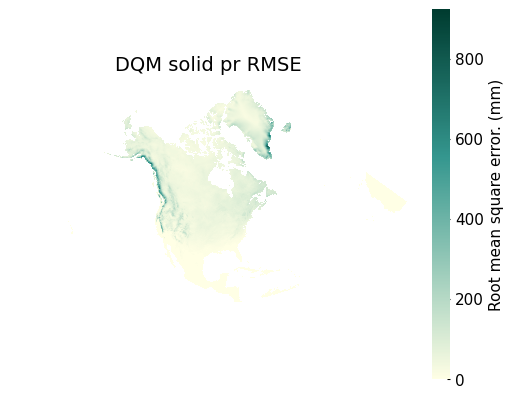

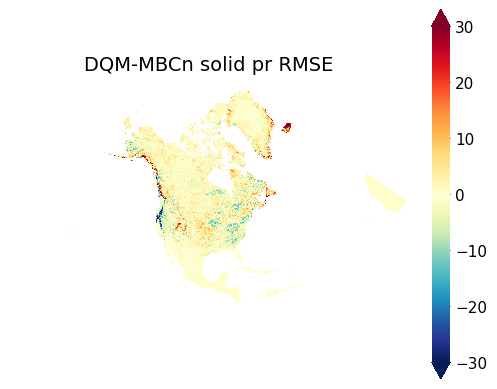

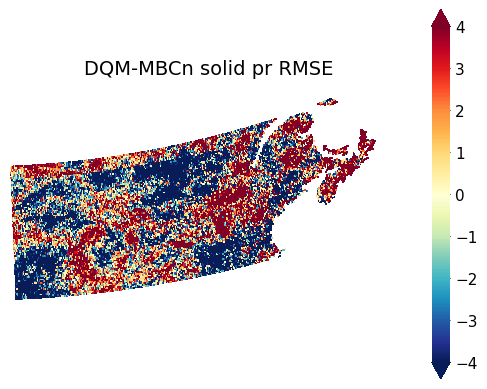

In [42]:
ds_mbcn=pcat.search(bias_adjust_project='MBCn',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_dqm=pcat.search(bias_adjust_project='DQM',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_ref=pcat.search(source='ERA5-Land',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_ref=ds_ref.convert_calendar('noleap')

ds_mbcn=ds_mbcn.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})
ds_dqm=ds_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
ds_ref=ds_ref.sel(time=slice('1991','2020')).isel(lat=slice(None,-1)).chunk({'time':-1})


ds_mbcn['tas']=xc.atmos.tg(ds=ds_mbcn)
ds_dqm['tas']=xc.atmos.tg(ds=ds_dqm)
ds_ref['tas']=xc.atmos.tg(ds=ds_ref)

spr_mbcn=xc.atmos.solid_precip_accumulation(ds=ds_mbcn)
spr_dqm=xc.atmos.solid_precip_accumulation(ds=ds_dqm)
spr_ref=xc.atmos.solid_precip_accumulation(ds=ds_ref)


rmse_mbcn= xa.measures.rmse(spr_mbcn, spr_ref)
rmse_dqm= xa.measures.rmse(spr_dqm, spr_ref)

ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
ax.set_title('MBCn solid pr RMSE')

ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
ax.set_title('DQM solid pr RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-30, 'vmax':30})
ax.set_title('DQM-MBCn solid pr RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, divergent=0,plot_kw={'vmin':-4, 'vmax':4})
ax.set_title('DQM-MBCn solid pr RMSE')
